In [10]:
import pandas as pd
import numpy as np
import lightkurve as lk
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('all_results_toP14.csv')
fraction_true = (df['Detection'] == 'True').sum() / len(df)
print(f"Detection True/Total Fraction: {fraction_true:.3f}")
toi_df = pd.read_csv('TOI_Mar2025_1pt5to4_R_with_Mst.csv')

df['TOI'] = df['TOI'].astype(str)
toi_df['toi'] = toi_df['toi'].astype(str)

df = df.merge(toi_df, left_on='TOI', right_on='toi', how='inner')
print(df['pl_orbper'].head)
print(df['True Period (Days)'].head)
#derived from histogram_rad_cliff.ipynb
# Using 3 n_transits and SNR = 2

# #rp_min = rs_earth * np.sqrt(snr_target * uncert / np.sqrt(n_trans))

temp_bins = [
    "3000-3500K", "3500-4000K", "4000-4500K", "4500-5000K",
    "5000-5500K", "5500-6000K", "6000-6500K", "6500-7000K"
]
min_radii = [1.40, 1.54, 1.79, 1.73, 1.87, 1.94, 2.31, 2.57]

min_detectable_df = pd.DataFrame({
    "Temperature Bin": temp_bins,
    "Minimum Detectable Planet Radius (Rearth)": min_radii
})

print(min_detectable_df)
#merge minimum planets to each row
def get_temp_bin(temp):
    for i, bin_label in enumerate(temp_bins):
        low, high = map(int, bin_label.replace('K', '').split('-'))
        if low <= temp < high:
            return bin_label
    return None

df['Temperature Bin'] = df['Stellar Temperature'].apply(get_temp_bin)
df_merged = df.merge(min_detectable_df, on='Temperature Bin', how='left')
print(df_merged)
df_above_min = df_merged[df_merged['True Radius (Earth Radii)'] > df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'{len(df_above_min)}/{len(df_merged)} planets above minimum detectable radius')

n_true = (df_above_min['Detection'] == 'True').sum()
n_false = (df_above_min['Detection'] == 'False').sum()
print(f"Above minimum detectable radius: Detection=True: {n_true}, Detection=False: {n_false}")

df_below_min = df_merged[df_merged['True Radius (Earth Radii)'] <= df_merged['Minimum Detectable Planet Radius (Rearth)']]
print(f'{len(df_below_min)}/{len(df_merged)} planets below minimum detectable radius')
n_true_below = (df_below_min['Detection'] == 'True').sum()
n_false_below = (df_below_min['Detection'] == 'False').sum()
print(f"Below minimum detectable radius: Detection=True: {n_true_below}, Detection=False: {n_false_below}")

Detection True/Total Fraction: 0.144
<bound method NDFrame.head of 0       3.577501
1       7.188733
2       1.917096
3       0.305261
4      12.302750
         ...    
729    13.823303
730    11.020153
731     2.573594
732     3.529850
733     4.327650
Name: pl_orbper, Length: 734, dtype: float64>
<bound method NDFrame.head of 0       3.6
1       7.2
2       1.9
3       0.3
4      12.3
       ... 
729    13.8
730    11.0
731     2.6
732     3.5
733     4.3
Name: True Period (Days), Length: 734, dtype: float64>
  Temperature Bin  Minimum Detectable Planet Radius (Rearth)
0      3000-3500K                                       1.40
1      3500-4000K                                       1.54
2      4000-4500K                                       1.79
3      4500-5000K                                       1.73
4      5000-5500K                                       1.87
5      5500-6000K                                       1.94
6      6000-6500K                                       

       TOI            TIC  CDPP (ppm)  Stellar Radius  Stellar Temperature  Stellar Magnitude  True Radius (Earth Radii)  True Period (Days) Detection  TLS Period  TLS Period Uncertainty  TLS Depth  TLS Rp/Rs  TLS FAP    TLS SNR     toi         id tfopwg_disp         rastr         ra         decstr        dec  st_pmra  st_pmraerr1  st_pmraerr2  st_pmralim  st_pmdec  st_pmdecerr1  st_pmdecerr2  st_pmdeclim    pl_tranmid  pl_tranmiderr1  pl_tranmiderr2  pl_tranmidlim  pl_orbper  pl_orbpererr1  pl_orbpererr2  pl_orbperlim  pl_trandurh  pl_trandurherr1  pl_trandurherr2  pl_trandurhlim   pl_trandep  pl_trandeperr1  pl_trandeperr2  pl_trandeplim   pl_rade  pl_radeerr1  pl_radeerr2  pl_radelim   pl_insol  pl_insolerr1  pl_insolerr2  pl_insollim      pl_eqt  pl_eqterr1  pl_eqterr2  pl_eqtlim  st_tmag  st_tmagerr1  st_tmagerr2  st_tmaglim  st_dist  st_disterr1  st_disterr2  st_distlim  st_teff  st_tefferr1  st_tefferr2  st_tefflim  st_logg  st_loggerr1  st_loggerr2  st_logglim    st_rad  st_rad

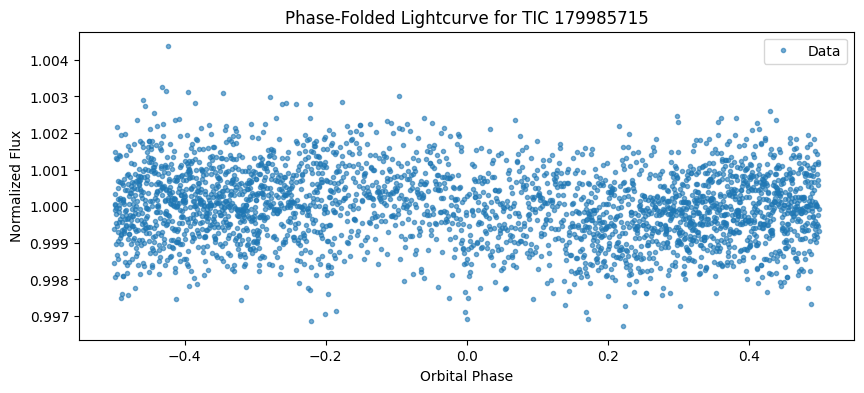

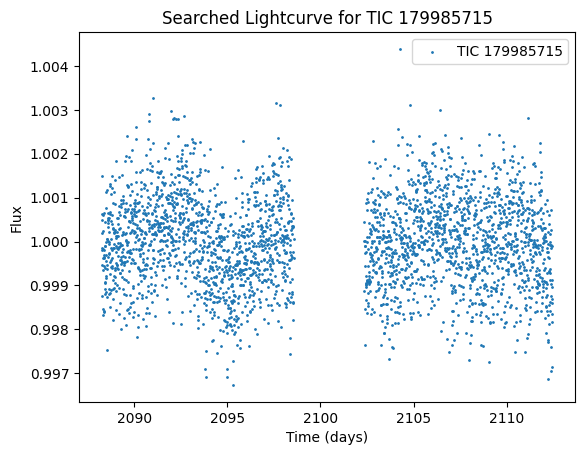

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 37 durations
Searching 2933 data points, 2160 periods from 0.601 to 12.104 days
Using all 10 CPU threads


100%|██████████| 2160/2160 periods | 00:04<00:00


Searching for best T0 for period 8.62649 days
FAP: 0.00040016, Period: 8.626485109612698, True Period: 6.6


In [18]:
from transitleastsquares import transitleastsquares
#TIC 106402532, TOI 733.01
toi = "249.01"
# Get the corresponding true period from df_above_min for this TIC
row = df_above_min[df_above_min['toi'] == toi]
print(row.to_string())
tic = row.iloc[0]['TIC'] if not row.empty else None
if not row.empty:
    true_period = row.iloc[0]['True Period (Days)']
else:
    true_period = np.nan

lc_collection = lk.search_lightcurve(tic, mission="TESS", cadence='long', author='TESS-SPOC').download_all(quality_bitmask="hard")
#print(lc_collection)
lc = lc_collection[-1].remove_nans().to_pandas().reset_index()
time = lc['time'].values
flux = lc['flux'].values
plt.figure(figsize=(10,4))


# Fix t0 to match TESS time
if not row.empty and 'pl_tranmid' in row.columns:
    t0 = row.iloc[0]['pl_tranmid'] - 2457000  # Correct time offset
else:
    t0 = np.nan

period = row.iloc[0]['pl_orbper']

# Proper phase folding
if not (np.isnan(true_period) or np.isnan(t0)):

    # Phase fold
    phase_fit = ((time - t0 + 0.5 * period) % period) / period - 0.5
    sorted_fit = np.argsort(phase_fit)


    flux = flux / np.nanmean(flux)
    plt.plot(phase_fit[sorted_fit], flux[sorted_fit], '.', label='Data', alpha=0.6)

    plt.xlabel("Orbital Phase")
    plt.ylabel("Normalized Flux")
    plt.title(f"Phase-Folded Lightcurve for {tic}")
    plt.legend()
    plt.show()
else:
    print("True period or t0 not found for phase folding.")

plt.scatter(time, flux, s=1, label=f'{tic}')
plt.title(f"Searched Lightcurve for {tic}")
plt.xlabel("Time (days)")
plt.ylabel("Flux")
plt.legend()
plt.show()
tls = transitleastsquares(time, flux)
result = tls.power()
print(f"FAP: {result.FAP}, Period: {result.period}, True Period: {true_period}")

#TIC 179985715, TOI 249.01